In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, classification_report
from sklearn.tree import plot_tree

In [2]:
# DATA LOADING & PREPROCESSING 
data = pd.read_csv("shop_smart_ecommerce.csv")

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [3]:
# Initialize LabelEncoder for categorical/boolean features
le = LabelEncoder()

# Encoding features to numerical format for the Decision Tree
categorical_cols = ["VisitorType", "Weekend", "Revenue", "Month"]
for col in categorical_cols:
    data[col] = le.fit_transform(data[col])

In [4]:
# FEATURE SELECTION & DATA SPLIT 
# Dropping redundant or high-cardinality features to reduce noise
X = data.drop(['Revenue', 'Browser', 'OperatingSystems', 'Region'], axis=1)
y = data['Revenue']

In [5]:
# Splitting data 
# stratify=y ensures the 85/15 class imbalance is maintained in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [6]:
# MODEL BUILDING
model = DecisionTreeClassifier()
model.fit(X_train,y_train)

# PREDICTION & EVALUATION 
y_pred = model.predict(X_test)

# F1 Score is our primary metric due to class imbalance (Benchmark: 0.55)
print(f"Final F1 Score: {f1_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Final F1 Score: 0.5353

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.92      0.92      2084
           1       0.54      0.53      0.54       382

    accuracy                           0.86      2466
   macro avg       0.73      0.72      0.73      2466
weighted avg       0.86      0.86      0.86      2466



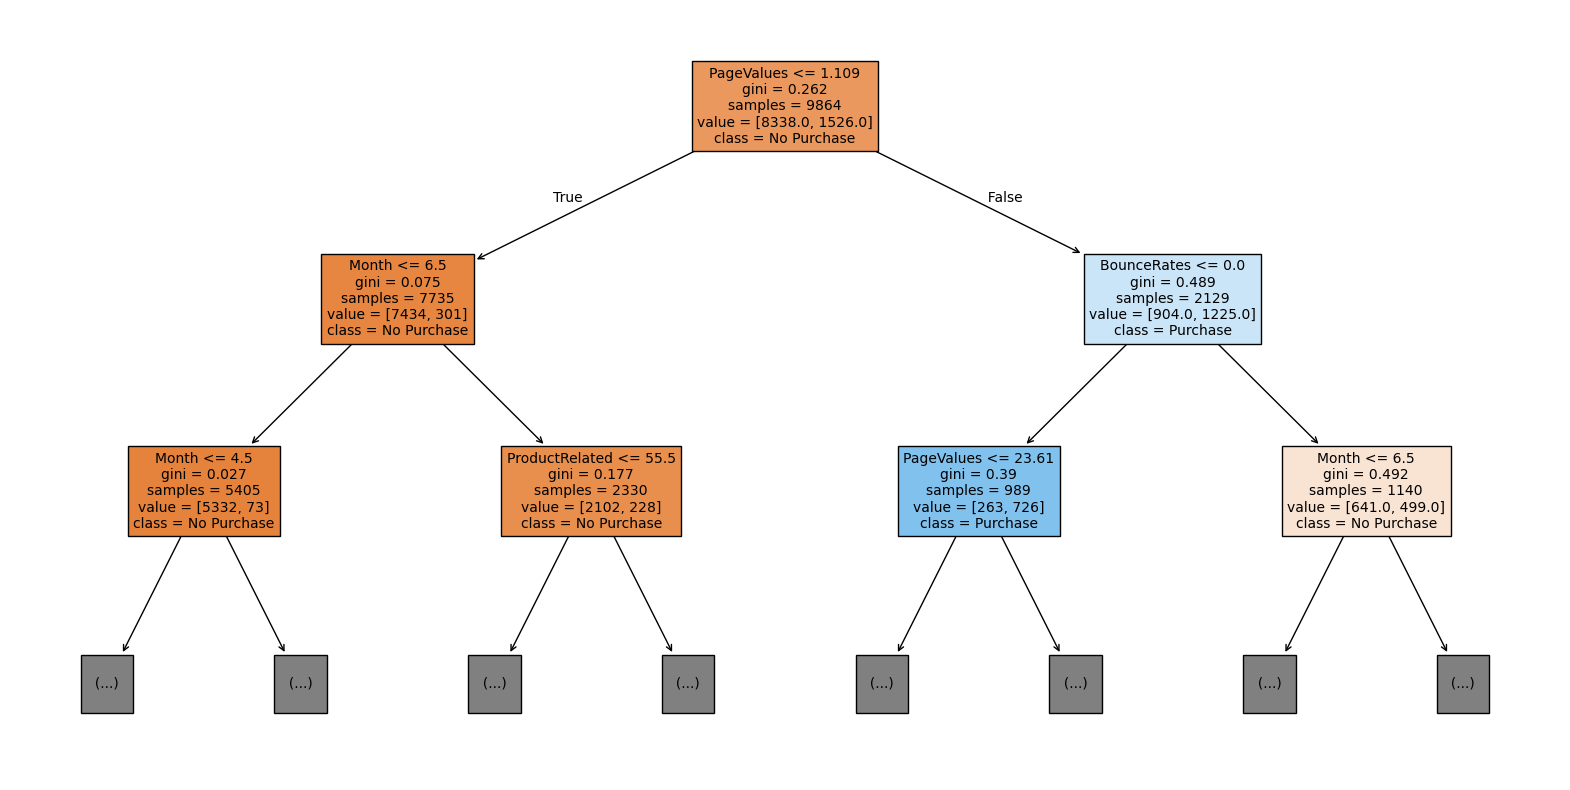

In [7]:
# DECISION TREE VISUALIZATION 
# 'max_depth=2' keeps the visualization clean while showing the most important features.
# 'filled=True' colors the nodes by class (Purchase vs No Purchase).
plt.figure(figsize=(20,10))
plot_tree(
    model, 
    filled=True, 
    feature_names=X.columns, 
    class_names=['No Purchase', 'Purchase'], 
    max_depth=2, 
    fontsize=10
)
plt.show()


# Pre Pruning

In [8]:
# MODEL BUILDING (PRE-PRUNING) 
# We use class_weight='balanced' to handle the 15% minority 'Purchase' class.
# Pre-pruning (max_depth) prevents the tree from overfitting the training noise.
model = DecisionTreeClassifier(
    max_depth=2, 
    min_samples_split=50, 
    class_weight='balanced', 
    random_state=42
)

model.fit(X_train, y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",50
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

In [9]:
y_pred = model.predict(X_test)

In [10]:
print(f"Final F1 Score: {f1_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Final F1 Score: 0.6485

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.89      0.92      2084
           1       0.55      0.78      0.65       382

    accuracy                           0.87      2466
   macro avg       0.76      0.83      0.78      2466
weighted avg       0.89      0.87      0.88      2466



# POST-PRUNING

In [11]:
# OPTIONAL: POST-PRUNING (Cost Complexity Pruning) 
# Using ccp_alpha to further simplify the tree by penalizing complexity
model_post = DecisionTreeClassifier(random_state=42, ccp_alpha=0.01, class_weight='balanced')
model_post.fit(X_train, y_train)
y_pred = model_post.predict(X_test)
print(f"Final F1 Score: {f1_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Final F1 Score: 0.6485

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.89      0.92      2084
           1       0.55      0.78      0.65       382

    accuracy                           0.87      2466
   macro avg       0.76      0.83      0.78      2466
weighted avg       0.89      0.87      0.88      2466



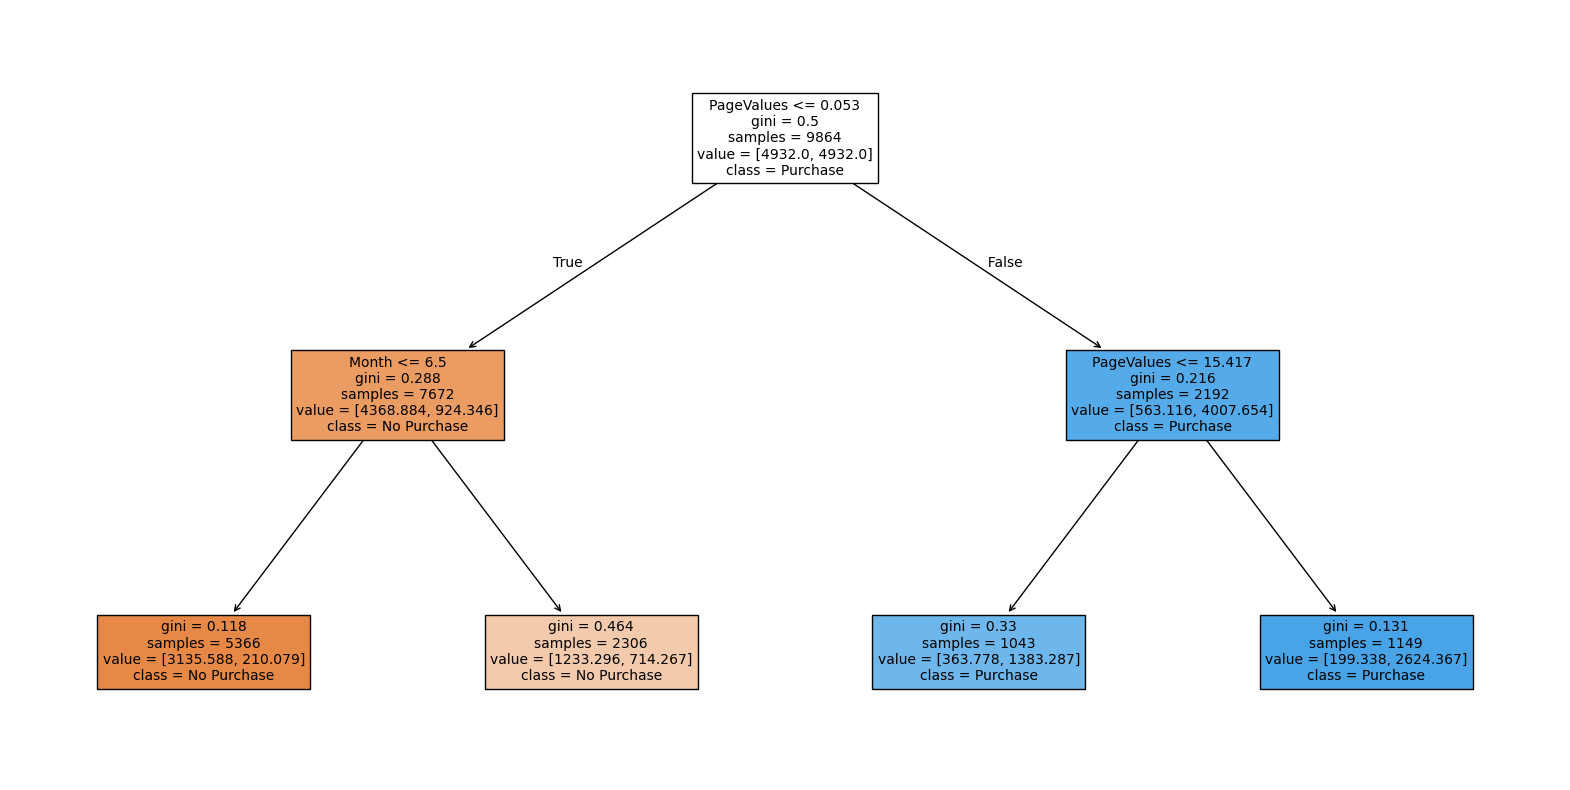

In [12]:
plt.figure(figsize=(20,10))
plot_tree(
    model, 
    filled=True, 
    feature_names=X.columns, 
    class_names=['No Purchase', 'Purchase'], 
    max_depth=2, 
    fontsize=10
)
plt.show()


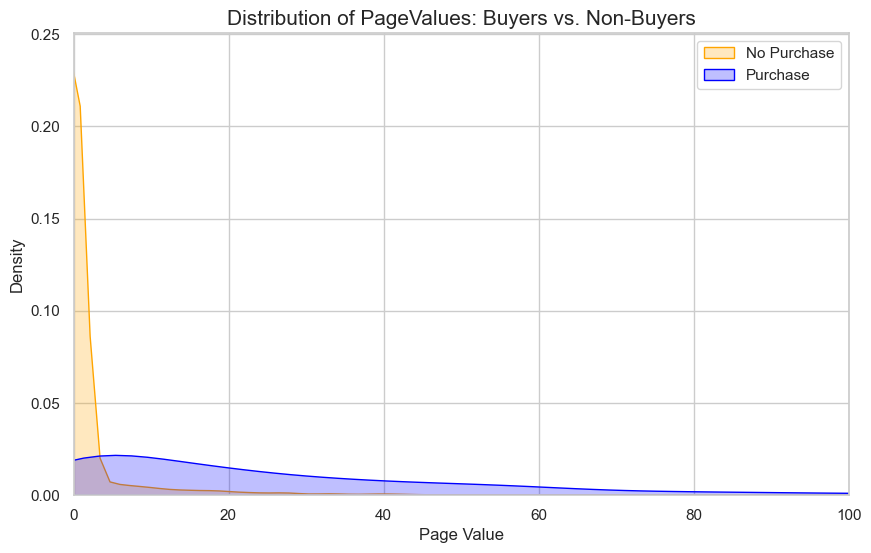

In [13]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

# Plotting the distribution of PageValues for both classes
sns.kdeplot(data=data[data['Revenue'] == 0]['PageValues'], label='No Purchase', fill=True, color='orange')
sns.kdeplot(data=data[data['Revenue'] == 1]['PageValues'], label='Purchase', fill=True, color='blue')

plt.title('Distribution of PageValues: Buyers vs. Non-Buyers', fontsize=15)
plt.xlabel('Page Value', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()

# Zooming in on the lower range where most data sits for better clarity
plt.xlim(0, 100) 
plt.show()
